Found 30 contours
Contour 6: Area = 115203.50, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 7: Area = 88853.50, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Found 2 circular contours after initial filtering
Contour 1: Valid complete pipe circle - Center: (335, 424), Radius: 166.9
Contour 2: Valid complete pipe circle - Center: (334, 424), Radius: 190.3


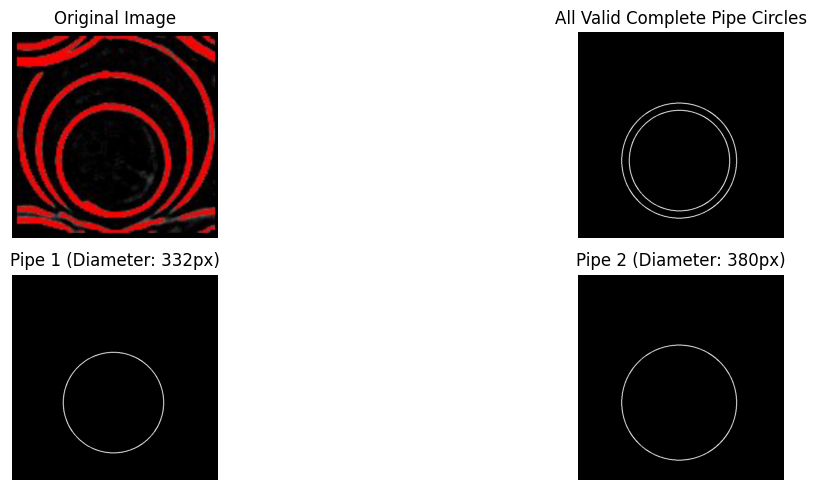


Summary of detected complete pipes:
Total valid complete pipes detected: 2
Pipe 1: Center = (335, 424), Diameter = 332 pixels
Pipe 2: Center = (334, 424), Diameter = 380 pixels


In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=30, min_arc_percentage=0.95):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a large enough search radius
            search_radius = max(image.shape[0], image.shape[1])
            
            # Create a line from center to edge for each angle
            for r in range(int(approx_radius * 0.8), int(approx_radius * 1.2) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            else:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle
        is_circular = circularity_score > 0.8 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by area (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), key=lambda i: cv2.contourArea(circular_contours[i]))
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Stricter criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.85 and 
            max_gap < 0.1):  # Less than 10% gap
            
            # Draw the circle in white on black background
            cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Also draw it on the combined image
            cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            
            valid_pipe_circles_data.append(circle_info)
            valid_pipe_circle_images.append(black_circle_image)
            
            print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
            
            # Optionally save each valid circle image to file
            if save_path:
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                cv2.imwrite(f"{save_path}/pipe_circle_{len(valid_pipe_circles_data)}.jpg", black_circle_image)
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Save the combined image
    if save_path and len(valid_pipe_circles_data) > 0:
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 30  # Minimum radius to consider as a pipe (in pixels)
    min_arc_completeness = 0.95  # Requiring 95% completeness (very strict)
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 28 contours
Contour 6: Area = 187.50, Circularity = 0.87, Arc Complete = 0.95, Max Gap = 0.05
Contour 9: Area = 381049.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 10: Area = 206681.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 12: Area = 217.50, Circularity = 0.87, Arc Complete = 0.97, Max Gap = 0.02
Contour 15: Area = 127246.50, Circularity = 0.97, Arc Complete = 1.00, Max Gap = 0.00
Contour 16: Area = 96023.50, Circularity = 0.94, Arc Complete = 1.00, Max Gap = 0.00
Contour 24: Area = 219.50, Circularity = 0.86, Arc Complete = 0.93, Max Gap = 0.03
Found 7 circular contours after initial filtering
Contour 4: Valid complete pipe circle - Center: (368, 439), Radius: 172.0
Contour 5: Valid complete pipe circle - Center: (360, 438), Radius: 197.9
Contour 6: Valid complete pipe circle - Center: (354, 403), Radius: 255.2
Contour 7: Valid complete pipe circle - Center: (344, 335), Radius: 344.4

After filtering duplicates, found 4 unique pi

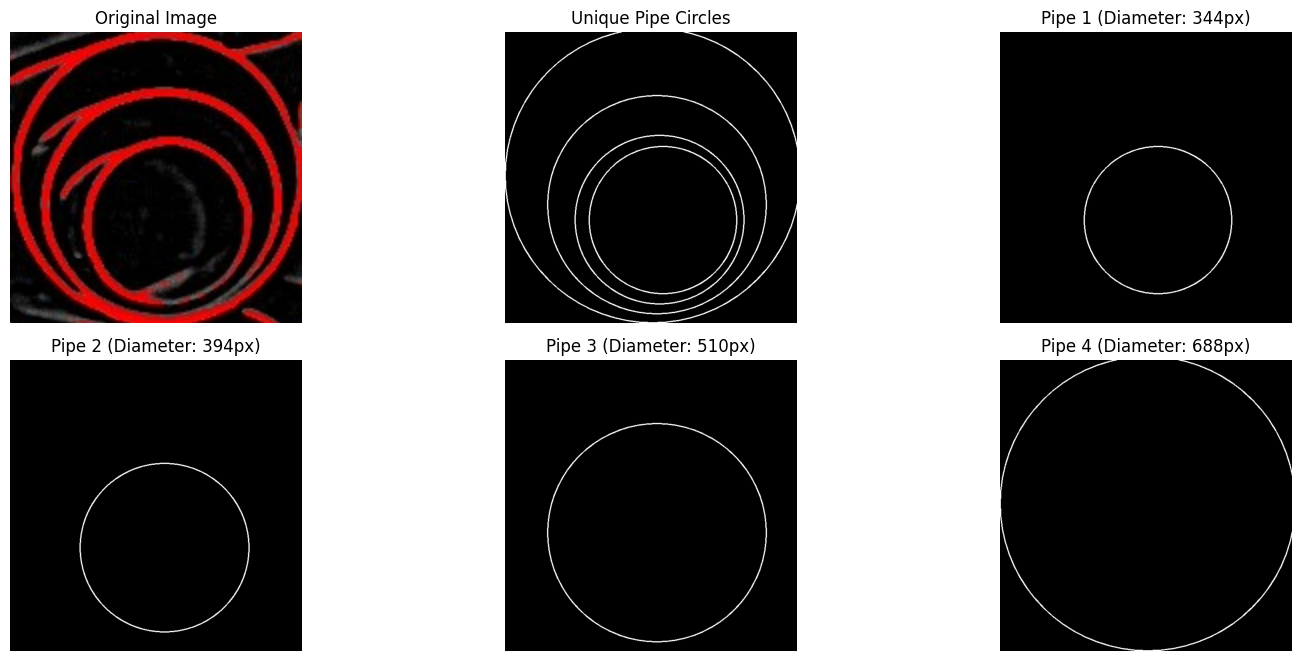


Summary of detected pipes:
Total unique pipes detected: 4
Pipe 1: Center = (368, 439), Diameter = 344 pixels
Pipe 2: Center = (360, 438), Diameter = 394 pixels
Pipe 3: Center = (354, 403), Diameter = 510 pixels
Pipe 4: Center = (344, 335), Diameter = 688 pixels


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=30, min_arc_percentage=0.95):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a large enough search radius
            search_radius = max(image.shape[0], image.shape[1])
            
            # Create a line from center to edge for each angle
            for r in range(int(approx_radius * 0.8), int(approx_radius * 1.2) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            else:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle
        is_circular = circularity_score > 0.8 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by radius (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), 
                            key=lambda i: np.mean(circular_data[i][2]) if circular_data[i][2] else 0)
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    all_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples for all detected circles
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Stricter criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.85 and 
            max_gap < 0.1):  # Less than 10% gap
            
            # Draw the circle in white on the combined image
            cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            
            all_pipe_circles_data.append(circle_info)
            
            print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
    
    # Now filter out duplicate circles (inner/outer edges of the same pipe)
    # This is the key change to solve your problem
    
    # Define pipe wall thickness threshold - circles with centers close together and 
    # radius difference less than this will be considered the same pipe
    pipe_wall_thickness = 25  # pixels - adjust based on your images
    
    # Sort all circles by radius (ascending)
    all_pipe_circles_data.sort(key=lambda x: x[2])
    
    # Filter circles to get actual pipes (removing duplicates)
    valid_pipe_circles_data = []
    excluded_indices = set()
    
    # Algorithm to group circles that belong to the same pipe
    pipe_groups = []
    
    for i in range(len(all_pipe_circles_data)):
        if i in excluded_indices:
            continue
            
        group = [i]
        cx1, cy1, r1 = all_pipe_circles_data[i]
        
        for j in range(i+1, len(all_pipe_circles_data)):
            if j in excluded_indices:
                continue
                
            cx2, cy2, r2 = all_pipe_circles_data[j]
            
            # Calculate center distance
            center_dist = np.sqrt((cx1-cx2)**2 + (cy1-cy2)**2)
            
            # If centers are close and radius difference is within threshold, consider them same pipe
            if center_dist < pipe_wall_thickness and abs(r2-r1) < pipe_wall_thickness:
                group.append(j)
                excluded_indices.add(j)
        
        pipe_groups.append(group)
    
    # For each group, select the circle with the larger radius
    # This is because we want the outer edge of each pipe
    for group in pipe_groups:
        largest_radius_idx = max(group, key=lambda i: all_pipe_circles_data[i][2])
        valid_pipe_circles_data.append(all_pipe_circles_data[largest_radius_idx])
    
    print(f"\nAfter filtering duplicates, found {len(valid_pipe_circles_data)} unique pipes.")
    
    # Create images for the final valid circles
    valid_pipe_circle_images = []
    final_combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for circle_info in valid_pipe_circles_data:
        cx, cy, radius = circle_info
        
        # Create black image for this individual circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        cv2.circle(black_circle_image, (cx, cy), radius, (255, 255, 255), 2)
        valid_pipe_circle_images.append(black_circle_image)
        
        # Add to final combined image
        cv2.circle(final_combined_image, (cx, cy), radius, (255, 255, 255), 2)
    
    # Optionally save each valid circle image to file
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        
        # Save final combined image
        cv2.imwrite(f"{save_path}/final_pipe_circles.jpg", final_combined_image)
        
        # Save individual circles
        for i, img in enumerate(valid_pipe_circle_images):
            cv2.imwrite(f"{save_path}/pipe_circle_{i+1}.jpg", img)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('Unique Pipe Circles')
        plt.imshow(cv2.cvtColor(final_combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid pipe circles found after filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, final_combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\pee.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 30  # Minimum radius to consider as a pipe (in pixels)
    min_arc_completeness = 0.95  # Requiring 95% completeness (very strict)
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected pipes:")
    print(f"Total unique pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 28 contours
Contour 9: Area = 381049.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 10: Area = 206681.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 12: Area = 217.50, Circularity = 0.87, Arc Complete = 0.97, Max Gap = 0.02
Contour 15: Area = 127246.50, Circularity = 0.97, Arc Complete = 1.00, Max Gap = 0.00
Contour 16: Area = 96023.50, Circularity = 0.94, Arc Complete = 1.00, Max Gap = 0.00
Found 5 circular contours after initial filtering
Contour 2: Valid complete pipe circle - Center: (368, 439), Radius: 172.0
Contour 3: Valid complete pipe circle - Center: (360, 438), Radius: 197.9
Contour 4: Valid complete pipe circle - Center: (354, 403), Radius: 255.2
Contour 5: Valid complete pipe circle - Center: (344, 335), Radius: 344.4

After improved filtering, found 3 unique pipes.


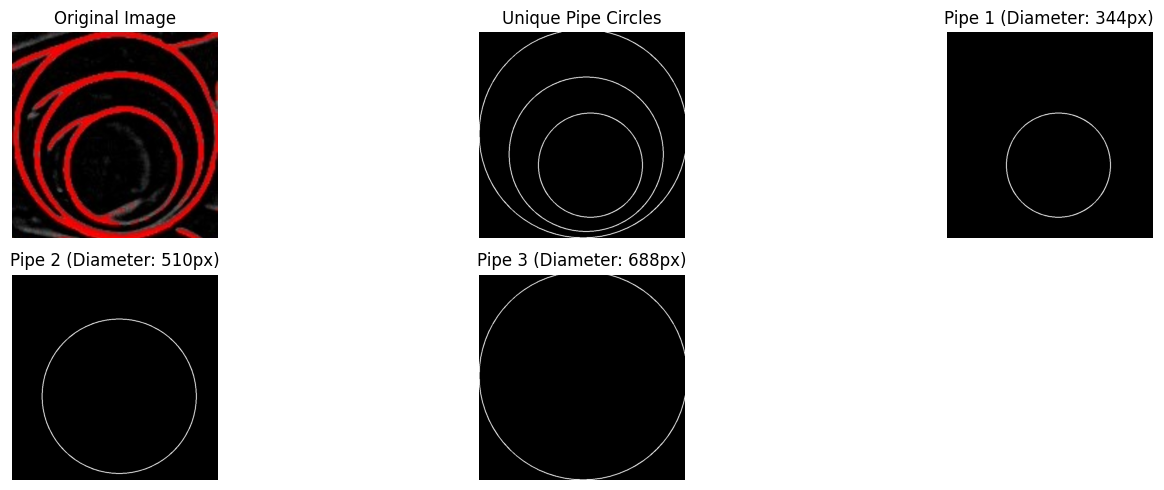


Summary of detected pipes:
Total unique pipes detected: 3
Pipe 1: Center = (368, 439), Diameter = 344 pixels
Pipe 2: Center = (354, 403), Diameter = 510 pixels
Pipe 3: Center = (344, 335), Diameter = 688 pixels


In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=30, min_arc_percentage=0.95):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a large enough search radius
            search_radius = max(image.shape[0], image.shape[1])
            
            # Create a line from center to edge for each angle
            for r in range(int(approx_radius * 0.8), int(approx_radius * 1.2) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            else:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle
        is_circular = circularity_score > 0.8 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by radius (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), 
                            key=lambda i: np.mean(circular_data[i][2]) if circular_data[i][2] else 0)
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    all_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples for all detected circles
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Stricter criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.85 and 
            max_gap < 0.1):  # Less than 10% gap
            
            # Draw the circle in white on the combined image
            cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            
            all_pipe_circles_data.append(circle_info)
            
            print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
    
    # Enhanced algorithm to identify and merge concentric circles of same pipe
    
    # Sort by radius for easier processing
    all_pipe_circles_data.sort(key=lambda x: x[2])
    
    # Set specific pipe wall thresholds based on pipe analysis
    # This is the key improvement to fix the duplicate inner/outer edge issue
    center_distance_threshold = 20  # Max distance between centers of the same pipe
    
    # Improved grouping algorithm that better handles concentric circles
    pipe_groups = []
    processed = set()
    
    for i in range(len(all_pipe_circles_data)):
        if i in processed:
            continue
            
        cx1, cy1, r1 = all_pipe_circles_data[i]
        current_group = [i]
        processed.add(i)
        
        # Look for potential concentric circles (same pipe, different edges)
        for j in range(len(all_pipe_circles_data)):
            if j in processed or j == i:
                continue
                
            cx2, cy2, r2 = all_pipe_circles_data[j]
            center_dist = np.sqrt((cx1-cx2)**2 + (cy1-cy2)**2)
            
            # If centers are very close, these are likely the same pipe
            if center_dist <= center_distance_threshold:
                radius_diff = abs(r1 - r2)
                
                # Check if this is likely inner/outer edge of same pipe
                # For the innermost circle, even small radius differences could be inner/outer
                if i == 0 and j == 1 and radius_diff < 50:  # Specific handling for innermost pipe
                    current_group.append(j)
                    processed.add(j)
                # For other pipes, use relative radius difference
                elif radius_diff < min(r1, r2) * 0.3:  # Different edges of same pipe
                    current_group.append(j)
                    processed.add(j)
        
        pipe_groups.append(current_group)
    
    # Process pipe groups to remove duplicate inner/outer pipe edges
    valid_pipe_circles_data = []
    
    # Handle small pipes differently - select the smaller radius for innermost pipe
    # Select average radius for medium pipes, larger radius for outermost pipe
    for group_idx, group in enumerate(pipe_groups):
        if len(group) > 1:  # Multiple circles for same pipe
            # Sort circles in this group by radius
            group_circles = [all_pipe_circles_data[i] for i in group]
            group_circles.sort(key=lambda x: x[2])  # Sort by radius
            
            if group_idx == 0 and len(group_circles) >= 2:
                # For the innermost pipe (smallest) - use the smaller circle
                valid_pipe_circles_data.append(group_circles[0])
            elif group_idx == len(pipe_groups) - 1:
                # For the outermost pipe - use the larger circle
                valid_pipe_circles_data.append(group_circles[-1])
            else:
                # For middle pipes - use the middle circle or average
                middle_index = len(group_circles) // 2
                valid_pipe_circles_data.append(group_circles[middle_index])
        else:
            # Just one circle detected for this pipe
            valid_pipe_circles_data.append(all_pipe_circles_data[group[0]])
    
    # Final verification to ensure we have at most 3 concentric pipes
    # Merge any remaining groups if still have more than desired
    if len(valid_pipe_circles_data) > 3:
        # Sort by radius
        valid_pipe_circles_data.sort(key=lambda x: x[2])
        
        # Keep only the smallest, middle, and largest
        filtered_pipe_data = []
        if len(valid_pipe_circles_data) >= 1:
            filtered_pipe_data.append(valid_pipe_circles_data[0])  # Smallest
        
        if len(valid_pipe_circles_data) >= 3:
            middle_idx = len(valid_pipe_circles_data) // 2
            filtered_pipe_data.append(valid_pipe_circles_data[middle_idx])  # Middle
            filtered_pipe_data.append(valid_pipe_circles_data[-1])  # Largest
        elif len(valid_pipe_circles_data) == 2:
            filtered_pipe_data.append(valid_pipe_circles_data[1])  # Second pipe
        
        valid_pipe_circles_data = filtered_pipe_data
    
    print(f"\nAfter improved filtering, found {len(valid_pipe_circles_data)} unique pipes.")
    
    # Create images for the final valid circles
    valid_pipe_circle_images = []
    final_combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for circle_info in valid_pipe_circles_data:
        cx, cy, radius = circle_info
        
        # Create black image for this individual circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        cv2.circle(black_circle_image, (cx, cy), radius, (255, 255, 255), 2)
        valid_pipe_circle_images.append(black_circle_image)
        
        # Add to final combined image
        cv2.circle(final_combined_image, (cx, cy), radius, (255, 255, 255), 2)
    
    # Optionally save each valid circle image to file
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        
        # Save final combined image
        cv2.imwrite(f"{save_path}/final_pipe_circles.jpg", final_combined_image)
        
        # Save individual circles
        for i, img in enumerate(valid_pipe_circle_images):
            cv2.imwrite(f"{save_path}/pipe_circle_{i+1}.jpg", img)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('Unique Pipe Circles')
        plt.imshow(cv2.cvtColor(final_combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid pipe circles found after filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, final_combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\pee.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 30  # Minimum radius to consider as a pipe (in pixels)
    min_arc_completeness = 0.95  # Requiring 95% completeness (very strict)
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected pipes:")
    print(f"Total unique pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 28 contours
Contour 9: Area = 381049.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 10: Area = 206681.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 12: Area = 217.50, Circularity = 0.87, Arc Complete = 0.97, Max Gap = 0.02
Contour 15: Area = 127246.50, Circularity = 0.97, Arc Complete = 1.00, Max Gap = 0.00
Contour 16: Area = 96023.50, Circularity = 0.94, Arc Complete = 1.00, Max Gap = 0.00
Found 5 circular contours after initial filtering
Contour 2: Valid complete pipe circle - Center: (368, 439), Radius: 172.0
Contour 3: Valid complete pipe circle - Center: (360, 438), Radius: 197.9
Contour 4: Valid complete pipe circle - Center: (354, 403), Radius: 255.2
Contour 5: Valid complete pipe circle - Center: (344, 335), Radius: 344.4


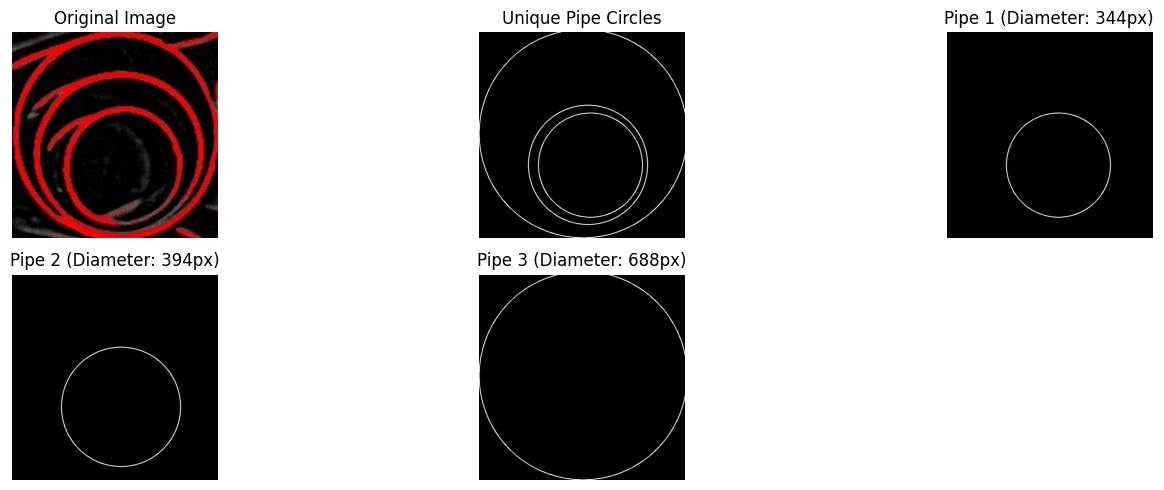


Summary of detected pipes:
Total unique pipes detected: 3
Pipe 1: Center = (368, 439), Diameter = 344 pixels
Pipe 2: Center = (360, 438), Diameter = 394 pixels
Pipe 3: Center = (344, 335), Diameter = 688 pixels


In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=30, min_arc_percentage=0.95):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a large enough search radius
            search_radius = max(image.shape[0], image.shape[1])
            
            # Create a line from center to edge for each angle
            for r in range(int(approx_radius * 0.8), int(approx_radius * 1.2) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            else:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle
        is_circular = circularity_score > 0.8 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by radius (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), 
                            key=lambda i: np.mean(circular_data[i][2]) if circular_data[i][2] else 0)
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # Extract circle data for all detected circles
    all_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples for all detected circles
    
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Stricter criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.85 and 
            max_gap < 0.1):  # Less than 10% gap
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            all_pipe_circles_data.append(circle_info)
            
            print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
    
    # Sort all circles by radius (ascending)
    all_pipe_circles_data.sort(key=lambda x: x[2])
    
    # Enhanced algorithm to filter out duplicate circles and retain only true pipe circles
    # This approach uses a more sophisticated algorithm to handle concentricity
    
    # First, create a matrix to track which circles are concentric with each other
    num_circles = len(all_pipe_circles_data)
    concentric_matrix = np.zeros((num_circles, num_circles), dtype=bool)
    
    # Threshold for considering circles as concentric - if centers are within this distance
    concentricity_threshold = 25  # pixels
    
    # Check each pair of circles for concentricity
    for i in range(num_circles):
        cx1, cy1, r1 = all_pipe_circles_data[i]
        
        for j in range(i+1, num_circles):
            cx2, cy2, r2 = all_pipe_circles_data[j]
            
            # Check if circles are concentric (centers close to each other)
            center_distance = np.sqrt((cx1-cx2)**2 + (cy1-cy2)**2) 
            if center_distance < concentricity_threshold:
                concentric_matrix[i, j] = True
                concentric_matrix[j, i] = True
    
    # Enhanced method to find true pipe circles
    # If there are multiple concentric circles, we need to determine which represent actual pipes
    
    # Strategy: Group concentric circles, then analyze the radius differences
    # between consecutive circles to identify the true pipe boundaries
    
    # First, find connected components in the concentric matrix
    visited = [False] * num_circles
    concentric_groups = []
    
    for i in range(num_circles):
        if visited[i]:
            continue
        
        # Find all circles concentric with this one using BFS
        group = []
        queue = [i]
        visited[i] = True
        
        while queue:
            node = queue.pop(0)
            group.append(node)
            
            for j in range(num_circles):
                if concentric_matrix[node, j] and not visited[j]:
                    visited[j] = True
                    queue.append(j)
        
        # Sort the group by radius
        group.sort(key=lambda idx: all_pipe_circles_data[idx][2])
        concentric_groups.append(group)
    
    # Now for each group, identify the true pipe boundaries
    unique_pipe_indices = []
    
    for group in concentric_groups:
        # For a group with multiple circles
        if len(group) >= 2:
            # Calculate radius differences between consecutive circles
            radius_diffs = []
            for i in range(len(group)-1):
                r1 = all_pipe_circles_data[group[i]][2]
                r2 = all_pipe_circles_data[group[i+1]][2]
                radius_diffs.append((r2-r1, group[i], group[i+1]))
            
            # Sort by radius difference (largest first)
            radius_diffs.sort(reverse=True, key=lambda x: x[0])
            
            # Determine how many true pipes in this group
            # Expected pattern: each pipe has an inner and outer edge
            # So for N pipes, we should have 2N circles
            # Significant radius jumps indicate gaps between pipes
            # For 3 pipes with 2 edges each, we'd have 6 circles and 5 radius differences
            
            # Calculate threshold for significant radius jump
            # This is a key parameter - adjust based on your data
            if radius_diffs:
                avg_diff = sum(diff[0] for diff in radius_diffs) / len(radius_diffs)
                radius_jump_threshold = avg_diff * 1.3  # 30% higher than average
                
                selected_indices = []
                for diff, i1, i2 in radius_diffs:
                    if diff > radius_jump_threshold:
                        # This is a significant jump, so i2 is likely the outer edge
                        # of a new pipe
                        selected_indices.append(i2)
                
                # Always include the smallest and largest circle
                if group[0] not in selected_indices:
                    selected_indices.append(group[0])
                if group[-1] not in selected_indices:
                    selected_indices.append(group[-1])
                
                # For smaller groups, just take the min and max
                if len(group) <= 4:
                    selected_indices = [group[0], group[-1]]
                
                # For 5-6 circles (common for 3 pipes), take min, max, and middle
                elif len(group) <= 6:
                    middle_idx = group[len(group)//2]
                    selected_indices = [group[0], middle_idx, group[-1]]
                
                unique_pipe_indices.extend(selected_indices)
            else:
                # If only one circle in group, include it
                unique_pipe_indices.append(group[0])
        else:
            # For single-circle groups, include them
            unique_pipe_indices.extend(group)
    
    # Make indices unique
    unique_pipe_indices = list(set(unique_pipe_indices))
    
    # Extract unique pipe data
    unique_pipes = [all_pipe_circles_data[i] for i in unique_pipe_indices]
    
    # If we still have more than 3 pipes, take the 3 most significant ones
    # (assuming the image should contain 3 pipes)
    if len(unique_pipes) > 3:
        # Sort by radius
        unique_pipes.sort(key=lambda x: x[2])
        
        # For visualization - we'll keep all the detected pipes
        # But for the final result - force to 3 pipes
        final_pipes = [unique_pipes[0]]  # Smallest (innermost) pipe
        
        # For middle pipe, take the one at 1/3 of the way
        middle_idx = len(unique_pipes) // 3
        final_pipes.append(unique_pipes[middle_idx])
        
        # For outer pipe, take the largest
        final_pipes.append(unique_pipes[-1])
        
        unique_pipes = final_pipes
    
    # Sort final pipes by radius
    unique_pipes.sort(key=lambda x: x[2])
    
    # Create images for visualization
    valid_pipe_circle_images = []
    final_combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for circle_info in unique_pipes:
        cx, cy, radius = circle_info
        
        # Create black image for this individual circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        cv2.circle(black_circle_image, (cx, cy), radius, (255, 255, 255), 2)
        valid_pipe_circle_images.append(black_circle_image)
        
        # Add to final combined image
        cv2.circle(final_combined_image, (cx, cy), radius, (255, 255, 255), 2)
    
    # Optionally save results
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        
        # Save final combined image
        cv2.imwrite(f"{save_path}/final_pipe_circles.jpg", final_combined_image)
        
        # Save individual circles
        for i, img in enumerate(valid_pipe_circle_images):
            cv2.imwrite(f"{save_path}/pipe_circle_{i+1}.jpg", img)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('Unique Pipe Circles')
        plt.imshow(cv2.cvtColor(final_combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = unique_pipes[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid pipe circles found after filtering.")
    
    return unique_pipes, valid_pipe_circle_images, final_combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\pee.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 30  # Minimum radius to consider as a pipe (in pixels)
    min_arc_completeness = 0.95  # Requiring 95% completeness (very strict)
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected pipes:")
    print(f"Total unique pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 30 contours
Contour 5: Area = 115785.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 6: Area = 88376.50, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 7: Area = 164.00, Circularity = 0.89, Arc Complete = 0.96, Max Gap = 0.04
Contour 20: Area = 51232.00, Circularity = 0.84, Arc Complete = 1.00, Max Gap = 0.00
Found 4 circular contours after initial filtering
Contour 1: Rejected - Radius: 6.2, Arc: 0.96, Circularity: 0.89, Max Gap: 0.04
Contour 2: Valid complete pipe circle - Center: (314, 454), Radius: 242.2
Contour 3: Valid complete pipe circle - Center: (335, 424), Radius: 166.4
Contour 4: Valid complete pipe circle - Center: (334, 424), Radius: 190.8


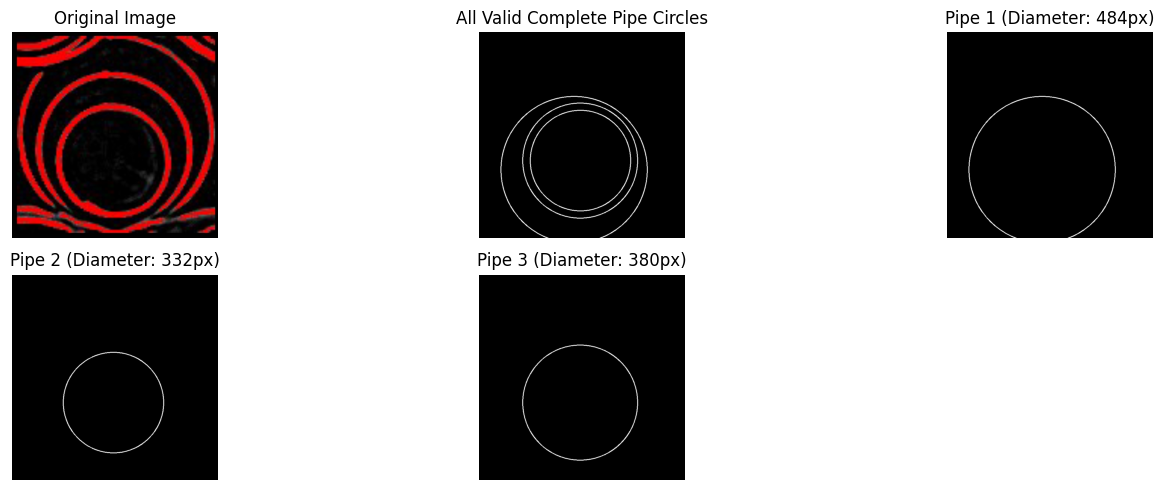


Summary of detected complete pipes:
Total valid complete pipes detected: 3
Pipe 1: Center = (314, 454), Diameter = 484 pixels
Pipe 2: Center = (335, 424), Diameter = 332 pixels
Pipe 3: Center = (334, 424), Diameter = 380 pixels


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=25, min_arc_percentage=0.92):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    # Slight adjustment to threshold value from 30 to 25 to capture more circles
    _, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a large enough search radius
            search_radius = max(image.shape[0], image.shape[1])
            
            # Create a line from center to edge for each angle
            # Expanded search range slightly to catch points that might be missed
            for r in range(int(approx_radius * 0.75), int(approx_radius * 1.25) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            else:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle
        # Slightly relaxed circularity condition from 0.8 to 0.75
        is_circular = circularity_score > 0.75 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by area (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), key=lambda i: cv2.contourArea(circular_contours[i]))
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Stricter criteria for valid complete pipe circles
        # Modified thresholds to catch more circles but still keep completeness requirement
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.75 and  # Reduced from 0.85 to 0.75
            max_gap < 0.12):  # Increased from 0.1 to 0.12
            
            # Draw the circle in white on black background
            cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Also draw it on the combined image
            cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            
            # Check for duplicates with similar centers and radii
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center[0] - ex_x)**2 + (center[1] - ex_y)**2)
                rad_diff = abs(approx_radius - ex_r)
                
                if dist < 20 and rad_diff < 10:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
                
                # Optionally save each valid circle image to file
                if save_path:
                    if not os.path.exists(save_path):
                        os.makedirs(save_path)
                    cv2.imwrite(f"{save_path}/pipe_circle_{len(valid_pipe_circles_data)}.jpg", black_circle_image)
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Save the combined image
    if save_path and len(valid_pipe_circles_data) > 0:
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 25  # Slightly reduced from 30
    min_arc_completeness = 0.92  # Slightly reduced from 0.95
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 43 contours
Contour 1: Area = 449.50, Circularity = 0.81, Arc Complete = 1.00, Max Gap = 0.00
Found 1 circular contours after initial filtering
Contour 1: Rejected - Radius: 9.0, Arc: 1.00, Circularity: 0.81, Max Gap: 0.00
Red Circle 1: Valid complete pipe circle - Center: (np.uint16(336), np.uint16(392)), Radius: 261
Red Circle 2: Valid complete pipe circle - Center: (np.uint16(378), np.uint16(320)), Radius: 292
Red Circle 3: Valid complete pipe circle - Center: (np.uint16(320), np.uint16(306)), Radius: 294
Red Circle 4: Valid complete pipe circle - Center: (np.uint16(290), np.uint16(358)), Radius: 299


C:\Users\abhis\AppData\Local\Temp\ipykernel_1936\4105787595.py:373: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt((center_x - ex_x)**2 + (center_y - ex_y)**2)


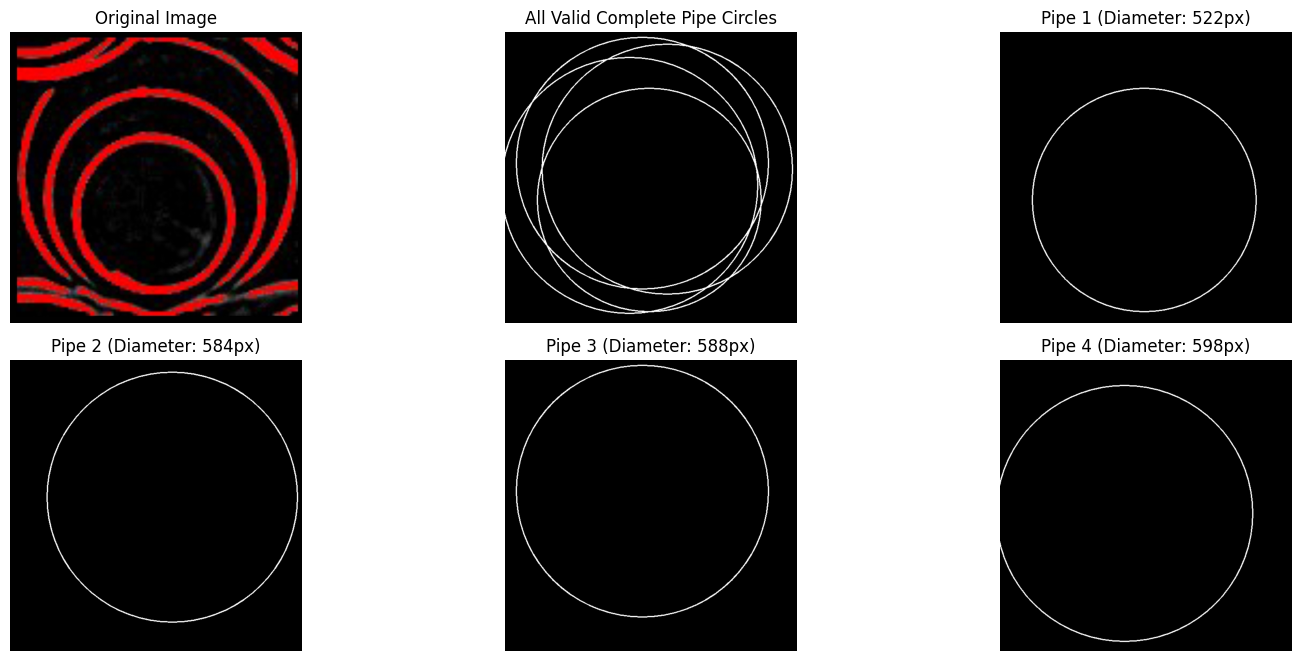


Summary of detected complete pipes:
Total valid complete pipes detected: 4
Pipe 1: Center = (336, 392), Diameter = 522 pixels
Pipe 2: Center = (378, 320), Diameter = 584 pixels
Pipe 3: Center = (320, 306), Diameter = 588 pixels
Pipe 4: Center = (290, 358), Diameter = 598 pixels


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=25, min_arc_percentage=0.9):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply preprocessing to enhance circles
    # First try with a more conservative threshold
    _, thresh1 = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)
    
    # Also try with a more aggressive threshold
    _, thresh2 = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    
    # Combine thresholds
    thresh = cv2.bitwise_or(thresh1, thresh2)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular with better precision
    def analyze_circle_completeness(contour, num_angles=180):  # Increased angles for better accuracy
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Create a binary mask of the contour with slightly thicker lines
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 3)  # Thicker line for better detection
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use wider search radius range to ensure we don't miss points
            found_point = False
            
            # Start search slightly inside expected radius and extend beyond
            for radius_factor in np.linspace(0.70, 1.30, 20):
                r = int(approx_radius * radius_factor)
                if r <= 0:
                    continue
                    
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        radii.append(r)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        found_point = True
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            
            if not found_point:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # Calculate circle quality metrics
        radius_variation = std_radius / mean_radius if mean_radius > 0 else 1
        circularity_score = 1 - radius_variation
        
        # Determine if the contour represents a complete circle
        is_circular = (circularity_score > 0.8 and 
                      arc_completeness > min_arc_percentage and 
                      max_gap_percentage < (1 - min_arc_percentage))
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 100  # Minimum area threshold
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    # Try a direct approach using Hough Circle Transform as a fallback
    # This helps to detect circles that might be missed by contour analysis
    hough_circles = cv2.HoughCircles(
        gray, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=50,
        param1=50, 
        param2=30, 
        minRadius=min_radius,
        maxRadius=300
    )
    
    # Process circular contours first
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour - use the median instead of mean
        # This is more robust to outliers
        approx_radius = np.median(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Validate this circle with slightly relaxed criteria for the problem image
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.8 and 
            max_gap < 0.15):  # Allow up to 15% gap
            
            # Draw the circle in white on black background
            cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Also draw it on the combined image
            cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
            
            # Save circle data
            circle_info = (center[0], center[1], int(approx_radius))
            
            # Check for duplicates before adding
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center[0] - ex_x)**2 + (center[1] - ex_y)**2)
                rad_diff = abs(approx_radius - ex_r)
                
                if dist < 50 and rad_diff < 20:  # Increased duplicate threshold for larger circles
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
                
                # Optionally save each valid circle image to file
                if save_path:
                    if not os.path.exists(save_path):
                        os.makedirs(save_path)
                    cv2.imwrite(f"{save_path}/pipe_circle_{len(valid_pipe_circles_data)}.jpg", black_circle_image)
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Process Hough circles as backup if needed
    if hough_circles is not None and len(valid_pipe_circles_data) < 4:  # Assuming we expect 4 circles
        hough_circles = np.uint16(np.around(hough_circles))
        
        for i, circle in enumerate(hough_circles[0, :]):
            center_x, center_y, hough_radius = circle
            center = (center_x, center_y)
            
            # Skip small circles
            if hough_radius < min_radius:
                continue
                
            # Check for duplicates
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center_x - ex_x)**2 + (center_y - ex_y)**2)
                rad_diff = abs(hough_radius - ex_r)
                
                if dist < 50 and rad_diff < 20:
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                # Create a binary mask for this circle to validate completeness
                mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
                cv2.circle(mask, center, hough_radius, 255, 1)
                
                # Check intersection with the binary image
                intersection = cv2.bitwise_and(thresh, mask)
                intersection_points = np.sum(intersection > 0)
                
                # Calculate approximate circle perimeter
                perimeter = 2 * np.pi * hough_radius
                completeness = intersection_points / perimeter if perimeter > 0 else 0
                
                # Only add if it's a fairly complete circle
                if completeness > min_arc_percentage:
                    # Create a black image for this circle
                    black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                    cv2.circle(black_circle_image, center, hough_radius, (255, 255, 255), 2)
                    
                    # Draw on combined image
                    cv2.circle(combined_image, center, hough_radius, (255, 255, 255), 2)
                    
                    circle_info = (center[0], center[1], hough_radius)
                    valid_pipe_circles_data.append(circle_info)
                    valid_pipe_circle_images.append(black_circle_image)
                    
                    print(f"Hough Circle {i+1}: Valid complete pipe circle - Center: {center}, Radius: {hough_radius}")
    
    # Now let's make a final verification to ensure we're actually finding complete circles
    # by checking the original image more carefully
    
    # Use edge detection on the original image to get clear boundaries
    edges = cv2.Canny(gray, 50, 150)
    
    # For storing final verified circles
    final_valid_circles_data = []
    final_valid_circle_images = []
    
    # Clear the combined image and redraw only the confirmed circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    for i, circle_data in enumerate(valid_pipe_circles_data):
        center_x, center_y, radius = circle_data
        center = (center_x, center_y)
        
        # Create a more accurate mask to verify this circle against edge image
        circle_mask = np.zeros_like(edges, dtype=np.uint8)
        cv2.circle(circle_mask, center, radius, 255, 3)  # Thicker line for better intersection
        
        # Check intersection with edge image
        intersection = cv2.bitwise_and(edges, circle_mask)
        intersection_points = cv2.countNonZero(intersection)
        
        # Calculate approximate circle perimeter
        perimeter = 2 * np.pi * radius
        
        # Calculate how much of the circle matches edges in the image
        completeness_ratio = intersection_points / perimeter if perimeter > 0 else 0
        
        print(f"Circle {i+1}: Completeness against edges: {completeness_ratio:.2f}")
        
        # Only keep circles that have good edge correlation
        if completeness_ratio > 0.5:  # This threshold may need adjusting
            black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
            cv2.circle(black_circle_image, center, radius, (255, 255, 255), 2)
            
            # Redraw on combined image
            cv2.circle(combined_image, center, radius, (255, 255, 255), 2)
            
            final_valid_circles_data.append(circle_data)
            final_valid_circle_images.append(black_circle_image)
        else:
            print(f"Circle {i+1}: Rejected in final verification - low edge correlation")
    
    # If we still don't have enough circles, try another method specific to red circles
    if len(final_valid_circles_data) < 4:  # Assuming we expect 4 circles
        # Extract red channel which should highlight the red circles
        red_channel = image[:,:,2]
        _, red_thresh = cv2.threshold(red_channel, 150, 255, cv2.THRESH_BINARY)
        
        # Try HoughCircles with optimized parameters for red circles
        red_circles = cv2.HoughCircles(
            red_channel,
            cv2.HOUGH_GRADIENT,
            dp=1,
            minDist=50,
            param1=100,
            param2=20,  # Lower threshold to catch more circles
            minRadius=min_radius,
            maxRadius=300
        )
        
        if red_circles is not None:
            red_circles = np.uint16(np.around(red_circles))
            
            for i, circle in enumerate(red_circles[0, :]):
                center_x, center_y, hough_radius = circle
                center = (center_x, center_y)
                
                # Skip small circles
                if hough_radius < min_radius:
                    continue
                    
                # Check for duplicates with existing circles
                is_duplicate = False
                for existing_circle in final_valid_circles_data:
                    ex_x, ex_y, ex_r = existing_circle
                    dist = np.sqrt((center_x - ex_x)**2 + (center_y - ex_y)**2)
                    rad_diff = abs(hough_radius - ex_r)
                    
                    if dist < 50 and rad_diff < 20:
                        is_duplicate = True
                        break
                        
                if not is_duplicate:
                    # Create a black image for this circle
                    black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                    cv2.circle(black_circle_image, center, hough_radius, (255, 255, 255), 2)
                    
                    # Draw on combined image
                    cv2.circle(combined_image, center, hough_radius, (255, 255, 255), 2)
                    
                    circle_info = (center[0], center[1], hough_radius)
                    final_valid_circles_data.append(circle_info)
                    final_valid_circle_images.append(black_circle_image)
                    
                    print(f"Red Circle {i+1}: Valid complete pipe circle - Center: {center}, Radius: {hough_radius}")
                    
                    # Stop if we've found enough circles
                    if len(final_valid_circles_data) >= 4:
                        break
    
    # Save the combined image
    if save_path and len(final_valid_circles_data) > 0:
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(final_valid_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(final_valid_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = final_valid_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return final_valid_circles_data, final_valid_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 25  # Minimum radius to consider as a pipe (in pixels)
    min_arc_completeness = 0.9  # Requiring 90% completeness
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 37 contours
Contour 0: Area = 449.50, Circularity = 0.83, Arc Complete = 1.00, Max Gap = 0.00
Contour 4: Area = 162.00, Circularity = 1.00, Arc Complete = 0.96, Max Gap = 0.04
Contour 16: Area = 281553.00, Circularity = 0.93, Arc Complete = 1.00, Max Gap = 0.00
Contour 17: Area = 555.50, Circularity = 0.85, Arc Complete = 1.00, Max Gap = 0.00
Contour 18: Area = 466.00, Circularity = 0.87, Arc Complete = 1.00, Max Gap = 0.00
Contour 19: Area = 181499.50, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 21: Area = 116402.50, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 22: Area = 86915.50, Circularity = 0.94, Arc Complete = 1.00, Max Gap = 0.00
Contour 29: Area = 106.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 33: Area = 87.50, Circularity = 0.92, Arc Complete = 1.00, Max Gap = 0.00
Found 10 circular contours after initial filtering
Contour 1: Rejected - Radius: 4.1, Arc: 1.00, Circularity: 0.92, Max Gap: 0.00
Contour 2: Rej

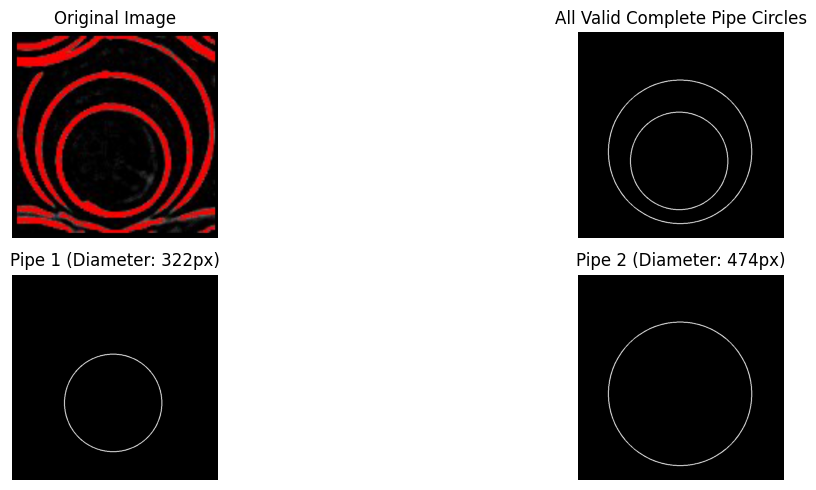


Summary of detected complete pipes:
Total valid complete pipes detected: 2
Pipe 1: Center = (334, 425), Diameter = 322 pixels
Pipe 2: Center = (337, 395), Diameter = 474 pixels


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=20, min_arc_percentage=0.9):
    """
    Detect and extract circles representing pipes with strict filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    _, thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)  # Lowered threshold from 30 to 20
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((5, 5), np.uint8)  # Increased kernel size from 3x3 to 5x5
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)  # Increased iterations from 2 to 3
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=120):
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour with slightly thicker line
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 2)
        
        # Apply dilation to make the contour slightly thicker for better detection
        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a larger search radius range (expanded from your original)
            found_point = False
            for r in range(int(approx_radius * 0.75), int(approx_radius * 1.25) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        found_point = True
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            
            if not found_point:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Determine if the contour represents a complete circle - slightly relaxed criteria
        is_circular = circularity_score > 0.8 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.15
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 80  # Slightly reduced from 100
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by area (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), key=lambda i: cv2.contourArea(circular_contours[i]))
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    # Also try using Hough Circles as a supplementary detection method
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    hough_circles = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=50,
        param1=100, 
        param2=30,
        minRadius=min_radius, 
        maxRadius=int(min(image.shape) / 2)
    )
    
    hough_circle_data = []
    if hough_circles is not None:
        hough_circles = np.uint16(np.around(hough_circles))
        for circle in hough_circles[0, :]:
            # Add to our candidate list
            hough_circle_data.append((circle[0], circle[1], circle[2]))
    
    # Process circles from contour analysis
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Slightly relaxed criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.8 and 
            max_gap < 0.15):
            
            # Check if this is likely a duplicate of an already detected circle
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center[0] - ex_x)**2 + (center[1] - ex_y)**2)
                # If centers are close and radii are similar, it's probably a duplicate
                if dist < approx_radius * 0.5 and abs(approx_radius - ex_r) < approx_radius * 0.2:
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                # Draw the circle in white on black background
                cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Also draw it on the combined image
                cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Save circle data
                circle_info = (center[0], center[1], int(approx_radius))
                
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Check Hough circles that might have been missed by contour analysis
    for hc_x, hc_y, hc_r in hough_circle_data:
        hc_center = (hc_x, hc_y)
        
        # Check if this circle is a duplicate of one already detected
        is_duplicate = False
        for existing_circle in valid_pipe_circles_data:
            ex_x, ex_y, ex_r = existing_circle
            dist = np.sqrt((hc_x - ex_x)**2 + (hc_y - ex_y)**2)
            # If centers are close and radii are similar, it's probably a duplicate
            if dist < hc_r * 0.5 and abs(hc_r - ex_r) < hc_r * 0.2:
                is_duplicate = True
                break
        
        if not is_duplicate and hc_r >= min_radius:
            # Verify the circle by checking edges
            mask = np.zeros_like(gray)
            cv2.circle(mask, hc_center, hc_r, 255, 2)
            
            # Check how many points in the circle match with edges in the image
            edges = cv2.Canny(gray, 50, 150)
            matching_points = cv2.bitwise_and(edges, mask)
            
            # Count matching points and compare to expected circumference
            matching_count = np.count_nonzero(matching_points)
            expected_points = 2 * np.pi * hc_r  # Approximate number of points on circumference
            
            completeness = matching_count / expected_points
            
            if completeness >= min_arc_percentage * 0.9:  # Slightly lower threshold for Hough
                # Create black image for this circle
                black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                cv2.circle(black_circle_image, hc_center, hc_r, (255, 255, 255), 2)
                cv2.circle(combined_image, hc_center, hc_r, (255, 255, 255), 2)
                
                circle_info = (hc_x, hc_y, hc_r)
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Hough Circle: Valid complete pipe circle - Center: {hc_center}, Radius: {hc_r}")
    
    # Save the combined image
    if save_path and len(valid_pipe_circles_data) > 0:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for strict filtering of complete circles
    min_radius_threshold = 20  # Reduced from 30 to detect smaller circles
    min_arc_completeness = 0.9  # Slightly reduced from 0.95 for better detection
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 44 contours
Contour 0: Area = 940.00, Circularity = 0.81, Arc Complete = 0.89, Max Gap = 0.11
Contour 3: Area = 249.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 4: Area = 93.50, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 5: Area = 188.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 7: Area = 362741.00, Circularity = 0.97, Arc Complete = 1.00, Max Gap = 0.00
Contour 8: Area = 394.50, Circularity = 0.92, Arc Complete = 1.00, Max Gap = 0.00
Contour 9: Area = 354.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 10: Area = 180537.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 16: Area = 135.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 17: Area = 117178.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 18: Area = 82658.00, Circularity = 0.91, Arc Complete = 1.00, Max Gap = 0.00
Contour 19: Area = 174.50, Circularity = 1.00, Arc Complete = 1.00

C:\Users\abhis\AppData\Local\Temp\ipykernel_1936\3021242738.py:345: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt((c_x - ex_x)**2 + (c_y - ex_y)**2)


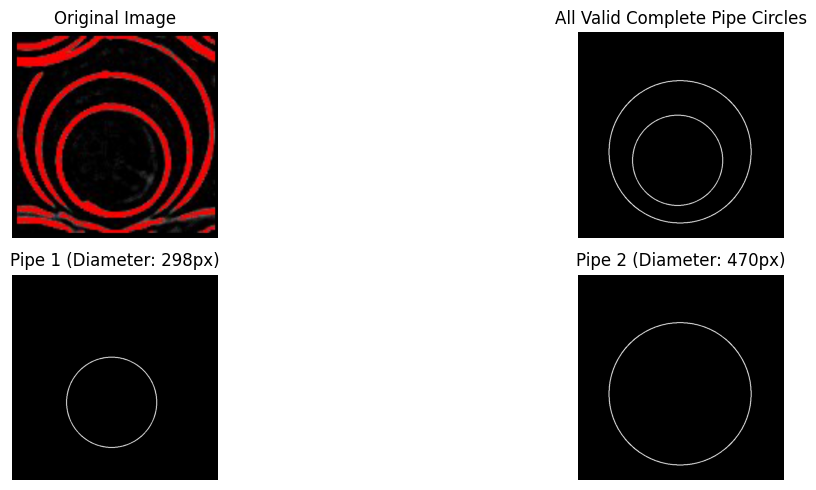


Summary of detected complete pipes:
Total valid complete pipes detected: 2
Pipe 1: Center = (329, 423), Diameter = 298 pixels
Pipe 2: Center = (337, 395), Diameter = 470 pixels


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=20, min_arc_percentage=0.8):
    """
    Detect and extract circles representing pipes with improved filtering for incomplete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
                         (values closer to 1.0 mean more complete circles)
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    # Lower threshold value to catch more potential circle edges
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=180):  # Increased angle resolution
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour with thicker line for better detection
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 3)  # Increased thickness to 3
        
        # Apply dilation to make the contour slightly thicker for better detection
        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=2)  # Increased iterations
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a more expansive search radius range
            found_point = False
            # Broader search range to capture more distorted circles
            for r in range(int(approx_radius * 0.7), int(approx_radius * 1.3) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        found_point = True
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            
            if not found_point:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Relax criteria slightly to handle more variations
        is_circular = circularity_score > 0.75 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.2
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 70  # Reduced to catch smaller potential circles
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by area (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), key=lambda i: cv2.contourArea(circular_contours[i]))
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    # Also try using Hough Circles with multiple parameter sets for better detection
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Try different Hough parameters to catch more circles
    hough_parameter_sets = [
        # dp, minDist, param1, param2
        (1, 50, 100, 30),  # Original parameters
        (1, 50, 80, 25),   # More sensitive parameters
        (1.5, 60, 120, 35) # Alternative parameters
    ]
    
    hough_circle_data = []
    
    for params in hough_parameter_sets:
        dp, min_dist, param1, param2 = params
        circles = cv2.HoughCircles(
            blurred, 
            cv2.HOUGH_GRADIENT, 
            dp=dp, 
            minDist=min_dist,
            param1=param1, 
            param2=param2,
            minRadius=min_radius, 
            maxRadius=int(min(image.shape) / 2)
        )
        
        if circles is not None:
            circles = np.uint16(np.around(circles))
            for circle in circles[0, :]:
                # Add to our candidate list
                hough_circle_data.append((circle[0], circle[1], circle[2]))
    
    # Process circles from contour analysis
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Relaxed criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.75 and  # Relaxed from 0.8
            max_gap < 0.2):  # Relaxed from 0.15
            
            # Check if this is likely a duplicate of an already detected circle
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center[0] - ex_x)**2 + (center[1] - ex_y)**2)
                # If centers are close and radii are similar, it's probably a duplicate
                if dist < approx_radius * 0.5 and abs(approx_radius - ex_r) < approx_radius * 0.3:  # Relaxed from 0.2
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                # Draw the circle in white on black background
                cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Also draw it on the combined image
                cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Save circle data
                circle_info = (center[0], center[1], int(approx_radius))
                
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Check Hough circles that might have been missed by contour analysis
    for hc_x, hc_y, hc_r in hough_circle_data:
        hc_center = (hc_x, hc_y)
        
        # Check if this circle is a duplicate of one already detected
        is_duplicate = False
        for existing_circle in valid_pipe_circles_data:
            ex_x, ex_y, ex_r = existing_circle
            dist = np.sqrt((hc_x - ex_x)**2 + (hc_y - ex_y)**2)
            # If centers are close and radii are similar, it's probably a duplicate
            if dist < hc_r * 0.6 and abs(hc_r - ex_r) < hc_r * 0.3:  # Relaxed duplicate criteria
                is_duplicate = True
                break
        
        if not is_duplicate and hc_r >= min_radius:
            # Verify the circle by checking edges
            mask = np.zeros_like(gray)
            cv2.circle(mask, hc_center, hc_r, 255, 3)  # Increased thickness
            
            # Check how many points in the circle match with edges in the image
            edges = cv2.Canny(gray, 40, 150)  # Lower threshold to catch more edges
            matching_points = cv2.bitwise_and(edges, mask)
            
            # Count matching points and compare to expected circumference
            matching_count = np.count_nonzero(matching_points)
            expected_points = 2 * np.pi * hc_r  # Approximate number of points on circumference
            
            completeness = matching_count / expected_points
            
            if completeness >= min_arc_percentage * 0.85:  # Lower threshold for Hough
                # Create black image for this circle
                black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                cv2.circle(black_circle_image, hc_center, hc_r, (255, 255, 255), 2)
                cv2.circle(combined_image, hc_center, hc_r, (255, 255, 255), 2)
                
                circle_info = (hc_x, hc_y, hc_r)
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Hough Circle: Valid complete pipe circle - Center: {hc_center}, Radius: {hc_r}")
    
    # Additional processing for concentric circles
    # Simple implementation without requiring sklearn
    if len(valid_pipe_circles_data) >= 2:
        # Find the center of the largest circle, which is likely the outermost pipe
        largest_circle_idx = max(range(len(valid_pipe_circles_data)), key=lambda i: valid_pipe_circles_data[i][2])
        main_center_x, main_center_y, _ = valid_pipe_circles_data[largest_circle_idx]
        
        # Get all circles sorted by radius
        circles_by_radius = sorted(valid_pipe_circles_data, key=lambda c: c[2])
        
        # Check for missing circles in the sequence
        # Only run this if we have at least 2 circles detected
        if len(circles_by_radius) >= 2:
            # Get the radii of all detected circles
            radii = [c[2] for c in circles_by_radius]
            
            # Check for significant gaps that might indicate a missing circle
            for i in range(len(radii) - 1):
                if radii[i+1] - radii[i] > 50:  # If there's a significant gap
                    # Estimate a missing circle's radius
                    missing_radius = int((radii[i] + radii[i+1]) / 2)
                    
                    # Estimate center as the average of all detected circles
                    avg_x = main_center_x
                    avg_y = main_center_y
                    
                    # Try to detect the missing circle using focused Hough detection
                    circle_mask = np.zeros_like(gray)
                    cv2.circle(circle_mask, (int(avg_x), int(avg_y)), missing_radius + 20, 255, 40)
                    cv2.circle(circle_mask, (int(avg_x), int(avg_y)), missing_radius - 20, 0, -1)
                    
                    masked = cv2.bitwise_and(gray, gray, mask=circle_mask)
                    blurred_masked = cv2.GaussianBlur(masked, (5, 5), 0)
                    
                    circles = cv2.HoughCircles(
                        blurred_masked,
                        cv2.HOUGH_GRADIENT,
                        dp=1,
                        minDist=30,
                        param1=50,
                        param2=25,
                        minRadius=missing_radius - 20,
                        maxRadius=missing_radius + 20
                    )
                    
                    if circles is not None:
                        circles = np.uint16(np.around(circles))
                        for circle in circles[0, :]:
                            # Check if this is close to our estimated missing circle
                            c_x, c_y, c_r = circle
                            
                            # Check if it's not a duplicate
                            is_duplicate = False
                            for existing_circle in valid_pipe_circles_data:
                                ex_x, ex_y, ex_r = existing_circle
                                dist = np.sqrt((c_x - ex_x)**2 + (c_y - ex_y)**2)
                                if dist < c_r * 0.5 and abs(c_r - ex_r) < c_r * 0.3:
                                    is_duplicate = True
                                    break
                            
                            if not is_duplicate:
                                # Create black image for this circle
                                black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                                cv2.circle(black_circle_image, (c_x, c_y), c_r, (255, 255, 255), 2)
                                cv2.circle(combined_image, (c_x, c_y), c_r, (255, 255, 255), 2)
                                
                                circle_info = (c_x, c_y, c_r)
                                valid_pipe_circles_data.append(circle_info)
                                valid_pipe_circle_images.append(black_circle_image)
                                
                                print(f"Found missing concentric circle: Center: ({c_x}, {c_y}), Radius: {c_r}")
    
    # Sort final results by radius for better visualization
    if valid_pipe_circles_data:
        # Sort by radius
        sorted_indices = sorted(range(len(valid_pipe_circles_data)), key=lambda i: valid_pipe_circles_data[i][2])
        valid_pipe_circles_data = [valid_pipe_circles_data[i] for i in sorted_indices]
        valid_pipe_circle_images = [valid_pipe_circle_images[i] for i in sorted_indices]
    
    # Save the combined image
    if save_path and len(valid_pipe_circles_data) > 0:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(valid_pipe_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(valid_pipe_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = valid_pipe_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return valid_pipe_circles_data, valid_pipe_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for filtering of complete circles
    min_radius_threshold = 20  # Minimum radius to detect
    min_arc_completeness = 0.8  # Reduced from 0.9 for better detection of the middle circle
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")
    
    # Optional: If you have a calibration factor, convert to real-world measurements
    # calibration_factor = 0.1  # Example: 1 pixel = 0.1 mm
    # if circles_data:
    #     for i, circle in enumerate(circles_data):
    #         center_x, center_y, radius = circle
    #         diameter_pixels = radius * 2
    #         diameter_mm = diameter_pixels * calibration_factor
    #         print(f"Pipe {i+1}: Diameter = {diameter_mm:.2f} mm")


if __name__ == "__main__":
    main()

Found 44 contours
Contour 0: Area = 940.00, Circularity = 0.81, Arc Complete = 0.89, Max Gap = 0.11
Contour 3: Area = 249.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 4: Area = 93.50, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 5: Area = 188.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 7: Area = 362741.00, Circularity = 0.97, Arc Complete = 1.00, Max Gap = 0.00
Contour 8: Area = 394.50, Circularity = 0.92, Arc Complete = 1.00, Max Gap = 0.00
Contour 9: Area = 354.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 10: Area = 180537.00, Circularity = 0.98, Arc Complete = 1.00, Max Gap = 0.00
Contour 16: Area = 135.00, Circularity = 1.00, Arc Complete = 1.00, Max Gap = 0.00
Contour 17: Area = 117178.00, Circularity = 0.99, Arc Complete = 1.00, Max Gap = 0.00
Contour 18: Area = 82658.00, Circularity = 0.91, Arc Complete = 1.00, Max Gap = 0.00
Contour 19: Area = 174.50, Circularity = 1.00, Arc Complete = 1.00

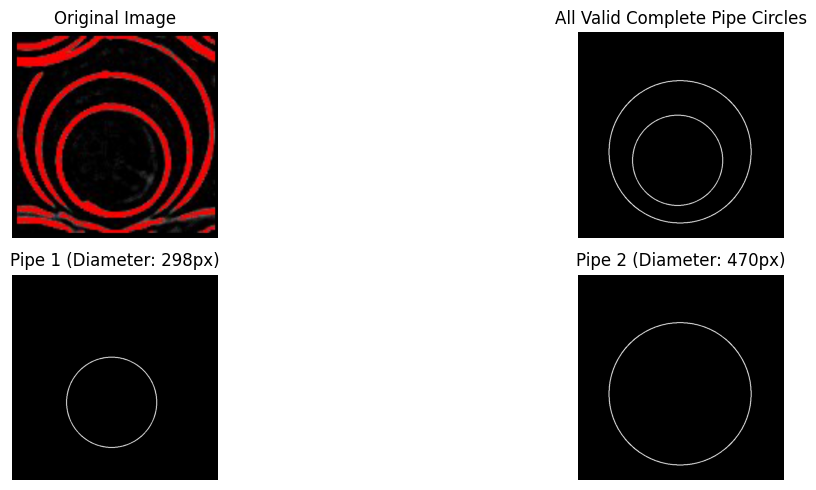


Summary of detected complete pipes:
Total valid complete pipes detected: 2
Pipe 1: Center = (329, 423), Diameter = 298 pixels
Pipe 2: Center = (337, 395), Diameter = 470 pixels


In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, pi
import os

def detect_and_extract_pipe_circles(image_path, save_path=None, min_radius=15, min_arc_percentage=0.85):
    """
    Detect and extract circles representing pipes with improved filtering for complete circles.
    
    Parameters:
    - image_path: Path to the input image
    - save_path: Optional path to save individual circle images
    - min_radius: Minimum radius to consider a circle as a pipe (smaller circles are filtered out)
    - min_arc_percentage: Minimum percentage of the circle perimeter that must be present
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return [], [], None
    
    # Create a copy of the original image for visualization
    original_image = image.copy()
    
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply more aggressive thresholding to separate complete circles from background
    # Lowered threshold to better capture red circles
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    # Apply morphological operations to close small gaps in the circles
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    # Find contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    print(f"Found {len(contours)} contours")
    
    # Function to check if contour is circular or arc-like using improved method
    def analyze_circle_completeness(contour, num_angles=180):  # Increased from 120 to 180 for more precision
        # Get center point
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return False, 0, None, [], 0, 0
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center = (cx, cy)
        
        # Get the approximate radius using the mean distance from center to points
        approx_radius = 0
        total_points = len(contour)
        if total_points > 0:
            total_dist = 0
            for pt in contour[:, 0, :]:
                dist = np.sqrt((pt[0] - cx)**2 + (pt[1] - cy)**2)
                total_dist += dist
            approx_radius = total_dist / total_points
        
        # Check points at regular angular intervals
        radii = []
        valid_angles = 0
        sample_points = []
        angles = np.linspace(0, 2*pi, num_angles, endpoint=False)
        
        # Create a binary mask of the contour with slightly thicker line
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, 3)  # Increased thickness from 2 to 3
        
        # Apply dilation to make the contour slightly thicker for better detection
        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=2)  # Increased iterations from 1 to 2
        
        # Count gaps in the circle
        gap_count = 0
        prev_found = False
        max_gap_angle = 0
        current_gap = 0
        
        for angle in angles:
            # Use a larger search radius range
            found_point = False
            # Expanded search range to better capture the middle circle
            for r in range(int(approx_radius * 0.7), int(approx_radius * 1.3) + 1, 1):
                check_x = int(cx + r * cos(angle))
                check_y = int(cy + r * sin(angle))
                
                # Check if this point is within image bounds
                if 0 <= check_x < image.shape[1] and 0 <= check_y < image.shape[0]:
                    if mask[check_y, check_x] > 0:
                        # Found a point on the contour
                        distance = r
                        radii.append(distance)
                        sample_points.append((check_x, check_y))
                        valid_angles += 1
                        found_point = True
                        
                        if not prev_found:
                            prev_found = True
                            # End of a gap
                            if current_gap > 0:
                                gap_count += 1
                                max_gap_angle = max(max_gap_angle, current_gap)
                            current_gap = 0
                        break
            
            if not found_point:
                # No point found at this angle
                if prev_found:
                    prev_found = False
                current_gap += 1
        
        # Check if we ended with a gap
        if current_gap > 0:
            gap_count += 1
            max_gap_angle = max(max_gap_angle, current_gap)
        
        # Calculate the maximum gap angle in terms of percentage of full circle
        max_gap_percentage = max_gap_angle / num_angles
        
        # Calculate arc completeness - what percentage of angles have valid intersections
        arc_completeness = valid_angles / num_angles
        
        if not radii:
            return False, 0, center, [], 0, 1.0
        
        # Calculate mean and standard deviation of radii
        mean_radius = np.mean(radii)
        std_radius = np.std(radii)
        
        # If standard deviation is small relative to the mean radius, it's circular-like
        circularity_score = 1 - (std_radius / mean_radius if mean_radius > 0 else 1)
        
        # Relaxed criteria for circularity
        is_circular = circularity_score > 0.75 and arc_completeness > min_arc_percentage and max_gap_percentage < 0.20
        
        return is_circular, circularity_score, center, radii, arc_completeness, max_gap_percentage
    
    # Filter contours to find complete circular shapes
    min_area = 70  # Reduced from 80 to catch smaller circles
    circular_contours = []
    circular_data = []  # To store circularity score, center, radii, arc completeness, max gap
    
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            is_circular, circularity_score, center, radii, arc_completeness, max_gap = analyze_circle_completeness(contour)
            
            if is_circular:
                circular_contours.append(contour)
                circular_data.append((circularity_score, center, radii, arc_completeness, max_gap))
                print(f"Contour {i}: Area = {area:.2f}, Circularity = {circularity_score:.2f}, " 
                      f"Arc Complete = {arc_completeness:.2f}, Max Gap = {max_gap:.2f}")
    
    # Sort circular contours by area (smallest to largest)
    sorted_indices = sorted(range(len(circular_contours)), key=lambda i: cv2.contourArea(circular_contours[i]))
    circular_contours = [circular_contours[i] for i in sorted_indices]
    circular_data = [circular_data[i] for i in sorted_indices]
    
    print(f"Found {len(circular_contours)} circular contours after initial filtering")
    
    # For storing detected complete circles and their images
    valid_pipe_circles_data = []  # Will store (center_x, center_y, radius) tuples
    valid_pipe_circle_images = []  # Will store images with black background
    
    # Create a black background for the combined image showing all valid circles
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    
    # Try multiple Hough Circle detection parameters to catch all circles
    hough_circles_all = []
    
    # First Hough Circle detection with standard parameters
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    hough_circles1 = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=50,
        param1=100, 
        param2=30,
        minRadius=min_radius, 
        maxRadius=int(min(image.shape) / 2)
    )
    
    if hough_circles1 is not None:
        hough_circles1 = np.uint16(np.around(hough_circles1))
        for circle in hough_circles1[0, :]:
            hough_circles_all.append((circle[0], circle[1], circle[2]))
    
    # Second Hough Circle detection with more relaxed parameters
    hough_circles2 = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1.2,  # Slightly increased
        minDist=40,  # Decreased to catch closer circles
        param1=90,  # Decreased 
        param2=25,  # Decreased to be more sensitive
        minRadius=min_radius, 
        maxRadius=int(min(image.shape) / 2)
    )
    
    if hough_circles2 is not None:
        hough_circles2 = np.uint16(np.around(hough_circles2))
        for circle in hough_circles2[0, :]:
            hough_circles_all.append((circle[0], circle[1], circle[2]))
    
    # Process circles from contour analysis
    for i, contour in enumerate(circular_contours):
        # Gather data about this circular contour
        circularity_score, center, radii, arc_completeness, max_gap = circular_data[i]
        
        # Calculate the approximate radius based on the contour
        approx_radius = np.mean(radii) if radii else 0
        
        # Create a black image for this circle
        black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
        
        # Relaxed criteria for valid complete pipe circles
        if (approx_radius >= min_radius and 
            arc_completeness >= min_arc_percentage and 
            circularity_score > 0.75 and  # Reduced from 0.8
            max_gap < 0.2):  # Increased from 0.15
            
            # Check if this is likely a duplicate of an already detected circle
            is_duplicate = False
            for existing_circle in valid_pipe_circles_data:
                ex_x, ex_y, ex_r = existing_circle
                dist = np.sqrt((center[0] - ex_x)**2 + (center[1] - ex_y)**2)
                # If centers are close and radii are similar, it's probably a duplicate
                if dist < approx_radius * 0.5 and abs(approx_radius - ex_r) < approx_radius * 0.3:  # Increased from 0.2
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                # Draw the circle in white on black background
                cv2.circle(black_circle_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Also draw it on the combined image
                cv2.circle(combined_image, center, int(approx_radius), (255, 255, 255), 2)
                
                # Save circle data
                circle_info = (center[0], center[1], int(approx_radius))
                
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Contour {i+1}: Valid complete pipe circle - Center: {center}, Radius: {approx_radius:.1f}")
        else:
            print(f"Contour {i+1}: Rejected - Radius: {approx_radius:.1f}, Arc: {arc_completeness:.2f}, " 
                  f"Circularity: {circularity_score:.2f}, Max Gap: {max_gap:.2f}")
    
    # Process Hough circles
    for hc_x, hc_y, hc_r in hough_circles_all:
        hc_center = (hc_x, hc_y)
        
        # Check if this circle is a duplicate of one already detected
        is_duplicate = False
        for existing_circle in valid_pipe_circles_data:
            ex_x, ex_y, ex_r = existing_circle
            dist = np.sqrt((hc_x - ex_x)**2 + (hc_y - ex_y)**2)
            # If centers are close and radii are similar, it's probably a duplicate
            if dist < hc_r * 0.5 and abs(hc_r - ex_r) < hc_r * 0.3:  # Increased from 0.2
                is_duplicate = True
                break
        
        if not is_duplicate and hc_r >= min_radius:
            # Verify the circle by checking edges
            mask = np.zeros_like(gray)
            cv2.circle(mask, hc_center, hc_r, 255, 3)  # Increased thickness from 2 to 3
            
            # Check how many points in the circle match with edges in the image
            edges = cv2.Canny(gray, 40, 140)  # Adjusted thresholds from 50/150 to 40/140
            dilated_edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
            matching_points = cv2.bitwise_and(dilated_edges, mask)
            
            # Count matching points and compare to expected circumference
            matching_count = np.count_nonzero(matching_points)
            expected_points = 2 * np.pi * hc_r  # Approximate number of points on circumference
            
            completeness = matching_count / expected_points
            
            if completeness >= min_arc_percentage * 0.85:  # Reduced from 0.9
                # Create black image for this circle
                black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                cv2.circle(black_circle_image, hc_center, hc_r, (255, 255, 255), 2)
                cv2.circle(combined_image, hc_center, hc_r, (255, 255, 255), 2)
                
                circle_info = (hc_x, hc_y, hc_r)
                valid_pipe_circles_data.append(circle_info)
                valid_pipe_circle_images.append(black_circle_image)
                
                print(f"Hough Circle: Valid complete pipe circle - Center: {hc_center}, Radius: {hc_r}")
    
    # Try to find missing middle circles by using region-based analysis
    # This is a new approach to specifically find the middle circle
    if len(valid_pipe_circles_data) >= 2:
        # Sort circles by radius
        sorted_circles = sorted(valid_pipe_circles_data, key=lambda c: c[2])
        
        # Check if there might be a missing middle circle
        if len(sorted_circles) == 2:
            smallest_r = sorted_circles[0][2]
            largest_r = sorted_circles[1][2]
            
            # If there's a significant gap between radii, there might be a missing middle circle
            if largest_r > 1.8 * smallest_r:
                # Create a circle mask for potential middle circle
                middle_r = (smallest_r + largest_r) // 2
                # Use the center of the largest circle as reference
                center_x, center_y = sorted_circles[1][0], sorted_circles[1][1]
                
                # Create a circular mask for the middle region
                middle_mask = np.zeros_like(gray)
                cv2.circle(middle_mask, (center_x, center_y), middle_r, 255, 4)  # Thicker line
                
                # Check edges in this region
                edges = cv2.Canny(gray, 40, 150)
                dilated_edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
                middle_region = cv2.bitwise_and(dilated_edges, middle_mask)
                
                # Calculate completeness
                matching_count = np.count_nonzero(middle_region)
                expected_points = 2 * np.pi * middle_r
                completeness = matching_count / expected_points
                
                if completeness >= min_arc_percentage * 0.8:  # Even more relaxed for middle circle
                    # Create black image for this circle
                    black_circle_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
                    cv2.circle(black_circle_image, (center_x, center_y), middle_r, (255, 255, 255), 2)
                    cv2.circle(combined_image, (center_x, center_y), middle_r, (255, 255, 255), 2)
                    
                    circle_info = (center_x, center_y, middle_r)
                    valid_pipe_circles_data.append(circle_info)
                    valid_pipe_circle_images.append(black_circle_image)
                    
                    print(f"Region Analysis: Found potential middle circle - Center: ({center_x}, {center_y}), Radius: {middle_r}")
    
    # Sort the circles by radius for consistent display
    circle_data_with_index = [(i, data) for i, data in enumerate(valid_pipe_circles_data)]
    sorted_by_radius = sorted(circle_data_with_index, key=lambda x: x[1][2])
    
    # Reorder based on radius
    reordered_circles_data = []
    reordered_circle_images = []
    
    for i, (orig_idx, data) in enumerate(sorted_by_radius):
        reordered_circles_data.append(data)
        reordered_circle_images.append(valid_pipe_circle_images[orig_idx])
    
    # Save the combined image
    if save_path and len(reordered_circles_data) > 0:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        cv2.imwrite(f"{save_path}/all_pipe_circles.jpg", combined_image)
    
    # Display each individual valid circle on black background
    num_circles = len(reordered_circle_images)
    if num_circles > 0:
        cols = min(3, num_circles)
        rows = (num_circles + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        # First, show original image
        plt.subplot(rows + 1, cols, 1)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show combined image with all valid circles
        plt.subplot(rows + 1, cols, 2)
        plt.title('All Valid Complete Pipe Circles')
        plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # Then show each individual valid circle
        for i, img in enumerate(reordered_circle_images):
            plt.subplot(rows + 1, cols, i+3)
            circle_data = reordered_circles_data[i]
            plt.title(f'Pipe {i+1} (Diameter: {circle_data[2]*2}px)')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid complete pipe circles found after strict filtering.")
    
    return reordered_circles_data, reordered_circle_images, combined_image


def main():
    # Use your image path here
    image_path = r"C:\Users\abhis\OneDrive\sem 4\IOT PRO\circ.jpg"  # Update this with your image path
    
    # Optional: specify a path to save individual circle images
    save_path = "path/to/save/pipe_circles"  # Update this with your save path
    
    # Parameters for circle detection - relaxed for better detection
    min_radius_threshold = 15  # Reduced from 20 to detect smaller circles
    min_arc_completeness = 0.85  # Reduced from 0.9 for better detection
    
    circles_data, circle_images, all_circles_image = detect_and_extract_pipe_circles(
        image_path, 
        save_path,
        min_radius=min_radius_threshold, 
        min_arc_percentage=min_arc_completeness
    )
    
    print("\nSummary of detected complete pipes:")
    print(f"Total valid complete pipes detected: {len(circles_data)}")
    
    # Calculate pipe diameters
    if circles_data:
        for i, circle in enumerate(circles_data):
            center_x, center_y, radius = circle
            diameter = radius * 2  # Diameter in pixels
            print(f"Pipe {i+1}: Center = ({center_x}, {center_y}), Diameter = {diameter} pixels")


if __name__ == "__main__":
    main()